# Texas Power Plants Map

Map of power plants in Texas with county boundaries.

- **County fill color:** Renewable share (0–100%) — *red* = low, *green* = high. Gray = no power plants.
- **Bubble color:** Energy source (Coal, Nuclear, Petroleum, Natural Gas, Hydropower, Wind, Solar, Biomass, Geothermal, All Other).
- **Bubble size:** Nameplate capacity bins — 0–50 MW, 50–100 MW, 100–200 MW, >200 MW.

In [82]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import contextily as ctx
from pathlib import Path
import numpy as np

BASE = Path(r"C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\texas cleaned")

def parse_centroid(col):
    def _to_point(s):
        if pd.isna(s):
            return None
        s = str(s).replace("�", "-").replace("−", "-").strip()
        parts = [p.strip() for p in s.split(",")]
        if len(parts) != 2:
            return None
        try:
            a, b = float(parts[0]), float(parts[1])
        except ValueError:
            return None
        if -110 <= a <= -90 and 25 <= b <= 40:
            return Point(a, b)
        if 25 <= a <= 40 and -110 <= b <= -90:
            return Point(b, a)
        return Point(a, b)
    return col.apply(_to_point)

print("Imports loaded.")

Imports loaded.


In [83]:
# Load power plants, filter to Texas only
df = pd.read_excel(BASE / "power_plants_texas (1)_cleaned.xlsx", sheet_name=0)
df = df[df["plant_state"].astype(str).str.upper().str.strip() == "TX"].copy()

geom = parse_centroid(df["Centroid"])
gdf = gpd.GeoDataFrame(df, geometry=geom, crs="EPSG:4326")
gdf = gdf.dropna(subset=["geometry"])

gdf["mw"] = pd.to_numeric(gdf["nameplate_capacity_mw (MW)"], errors="coerce").fillna(0)

# Map EIA energy_source_code to user categories
ENERGY_CATEGORY = {
    "Coal": {"SUB", "LIG", "BIT", "ANT", "RC", "SGC", "WC"},
    "Nuclear": {"NUC"},
    "Petroleum": {"DFO", "JF", "KER", "PC", "RFO", "WO"},
    "Natural Gas and other Gases": {"NG", "BFG", "LFG", "OG", "OBG", "PG", "SG"},
    "Hydropower": {"WAT", "HYC"},
    "Wind": {"WND"},
    "Solar": {"SUN"},
    "Biomass": {"AB", "BLQ", "MSB", "OBL", "SLW", "TIR", "WDS"},
    "Geothermal": {"GEO"},
}
def code_to_category(code):
    c = str(code).strip().upper()
    for cat, codes in ENERGY_CATEGORY.items():
        if c in codes:
            return cat
    return "All Other"

gdf["energy_category"] = gdf["energy_source_code"].apply(code_to_category)

# Capacity bins (MW) -> marker size
def mw_to_size(mw):
    if mw <= 50: return 15
    if mw <= 100: return 35
    if mw <= 200: return 60
    return 95
gdf["size_bin"] = gdf["mw"].apply(mw_to_size)

print(f"Texas power plants: {len(gdf)}")
print("Energy categories:", gdf["energy_category"].value_counts().to_string())

Texas power plants: 3105
Energy categories: energy_category
Natural Gas and other Gases    1650
Solar                           378
Petroleum                       339
All Other                       336
Wind                            283
Hydropower                       53
Coal                             44
Biomass                          18
Nuclear                           4


In [84]:
# Load Texas county boundaries (Census TIGER)
# Uses cached file if available; otherwise downloads from Census (~80MB, 1-2 min first time)
RENEWABLE_CODES = {"SUN", "WND", "WAT", "LFG", "WDS", "AB"}

CACHE_PATH = BASE / "texas_counties_cache.gpkg"
if CACHE_PATH.exists():
    counties = gpd.read_file(CACHE_PATH)
    print("Loaded Texas counties from cache.")
else:
    counties = None
    for url in [
        "https://www2.census.gov/geo/tiger/TIGER2024/COUNTY/tl_2024_us_county.zip",
        "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip",
    ]:
        try:
            print("Downloading counties from Census (~80MB, may take 1-2 min)...")
            all_counties = gpd.read_file(url)
            counties = all_counties[all_counties["STATEFP"] == "48"].copy()
            counties.to_file(CACHE_PATH, driver="GPKG")
            print("Loaded and cached Texas counties.")
            break
        except Exception as e:
            print(f"Failed: {e}")
            continue
    if counties is None:
        raise RuntimeError("Could not download county boundaries. Check internet connection.")

counties = counties.to_crs("EPSG:4326")
counties["NAME"] = counties["NAME"].str.strip()

# Aggregate power plants by county: total MW and renewable MW
gdf["mw"] = gdf["nameplate_capacity_mw (MW)"].fillna(0)
gdf["renewable_mw"] = gdf.apply(
    lambda r: r["mw"] if str(r["energy_source_code"]).strip() in RENEWABLE_CODES else 0, axis=1
)
by_county = gdf.groupby("county").agg(total_mw=("mw", "sum"), renewable_mw=("renewable_mw", "sum")).reset_index()
by_county["renewable_share"] = np.where(
    by_county["total_mw"] > 0,
    by_county["renewable_mw"] / by_county["total_mw"],
    np.nan
)

# Join to county geometries (match county name; normalize for merge)
counties["county_key"] = counties["NAME"].str.strip().str.title()
by_county["county_key"] = by_county["county"].str.strip().str.title()
merged = counties.merge(by_county, on="county_key", how="left")
merged["renewable_share"] = merged["renewable_share"].fillna(-1)  # -1 = no plants

matched = merged["total_mw"].notna().sum()
print(f"Counties with power plants matched: {matched} / {len(by_county)}")
cols = ["NAME", "total_mw", "renewable_mw", "renewable_share"]
print("Renewable share by county (sample):")
print(merged[cols].dropna(subset=["total_mw"]).head(10).to_string())

Loaded Texas counties from cache.
Counties with power plants matched: 221 / 223
Renewable share by county (sample):
         NAME  total_mw  renewable_mw  renewable_share
0      Menard       7.5           7.5         1.000000
1        Hale    1644.6         478.0         0.290648
2   Armstrong     265.5         265.5         1.000000
3     Calhoun     261.0           0.0         0.000000
4     Calhoun    1848.1         196.3         0.106217
5        Clay     654.0         654.0         1.000000
6      Orange    4129.0           0.0         0.000000
7    Gonzales       4.8           4.8         1.000000
8      Fannin    1585.7         216.6         0.136596
10    Refugio     220.0         220.0         1.000000


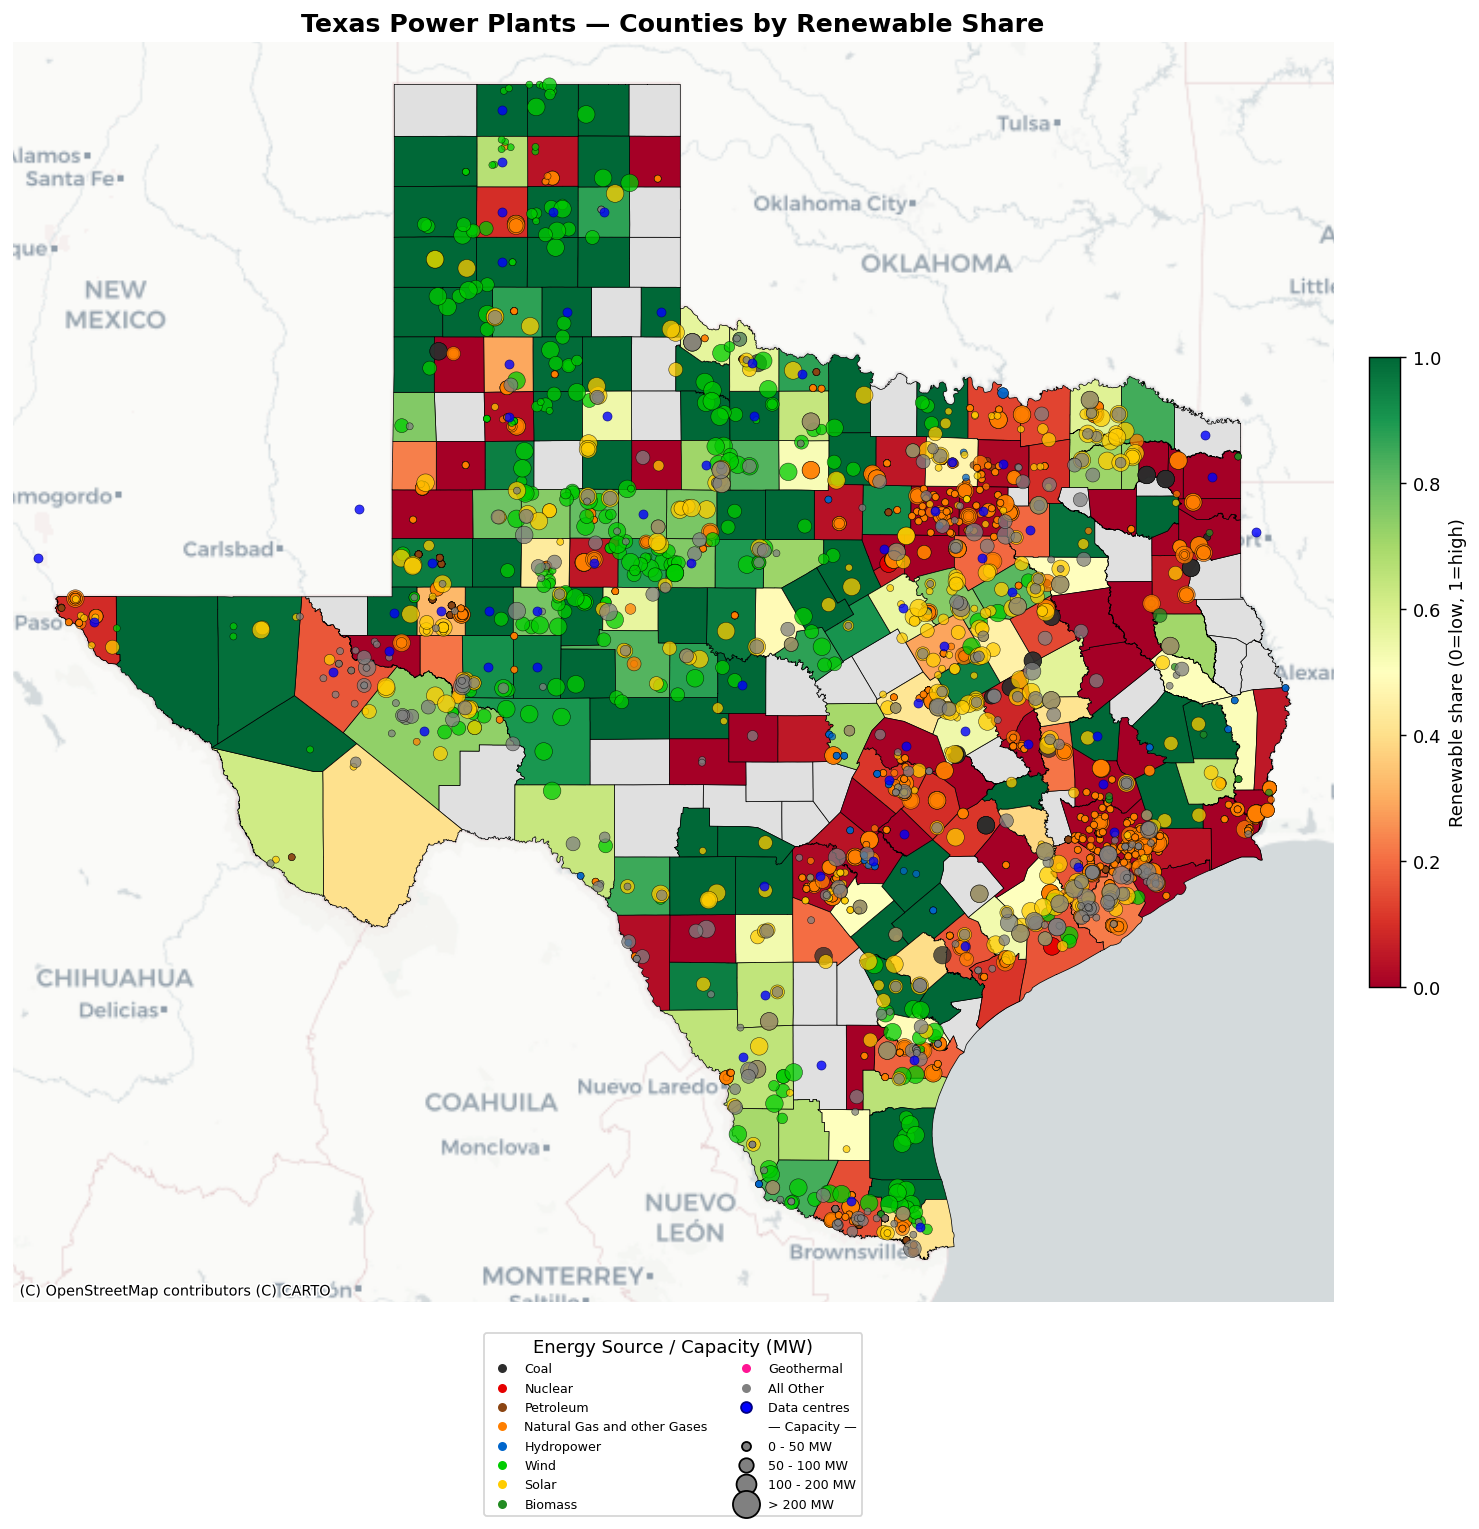

In [85]:
# Map: counties colored by renewable share, county boundaries, power plant bubbles
merged_3857 = merged.to_crs(epsg=3857)
gdf_3857 = gdf.to_crs(epsg=3857)

# Load data centres and place using Centroid column
dc_path = Path(r"C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\data_centres_doe_texas.xlsx")
dc = pd.read_excel(dc_path, sheet_name=0)
dc_geom = parse_centroid(dc["Centroid"])
gdf_dc = gpd.GeoDataFrame(dc, geometry=dc_geom, crs="EPSG:4326").dropna(subset=["geometry"])
gdf_dc_3857 = gdf_dc.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(14, 12), dpi=130)
ax.set_title("Texas Power Plants — Counties by Renewable Share", fontsize=14, fontweight="bold")

# Texas extent (Web Mercator)
xmin, ymin, xmax, ymax = merged_3857.total_bounds
buffer = 50000
ax.set_xlim(xmin - buffer, xmax + buffer)
ax.set_ylim(ymin - buffer, ymax + buffer)
ax.set_aspect("equal")

# 1. County fill: renewable share (0=red, 1=green). Gray = no plants.
#    County boundaries in black for visibility.
has_data = merged_3857["renewable_share"] >= 0
merged_3857[~has_data].plot(ax=ax, color="#e0e0e0", edgecolor="black", linewidth=0.4)
merged_3857[has_data].plot(
    ax=ax, column="renewable_share", cmap="RdYlGn", vmin=0, vmax=1,
    edgecolor="black", linewidth=0.4, legend=True,
    legend_kwds={"label": "Renewable share (0=low, 1=high)", "shrink": 0.5, "pad": 0.02}
)

# 3. Power plant bubbles: size = capacity bin, color = energy category
CATEGORY_ORDER = [
    "Coal", "Nuclear", "Petroleum", "Natural Gas and other Gases",
    "Hydropower", "Wind", "Solar", "Biomass", "Geothermal", "All Other"
]
COLORS = {
    "Coal": "#2d2d2d",
    "Nuclear": "#e60000",
    "Petroleum": "#8b4513",
    "Natural Gas and other Gases": "#ff7f00",
    "Hydropower": "#0066cc",
    "Wind": "#00cc00",
    "Solar": "#ffcc00",
    "Biomass": "#228b22",
    "Geothermal": "#ff1493",
    "All Other": "#808080",
}
for cat in CATEGORY_ORDER:
    subset = gdf_3857[gdf_3857["energy_category"] == cat]
    if subset.empty:
        continue
    subset.plot(ax=ax, markersize=subset["size_bin"], color=COLORS.get(cat, "#808080"),
                alpha=0.75, edgecolor="black", linewidth=0.3, label=cat)

# Data centre dots (blue), placed using Centroid column
if not gdf_dc_3857.empty:
    gdf_dc_3857.plot(ax=ax, color="blue", markersize=25, alpha=0.8, edgecolor="navy", linewidth=0.4, label="Data centres")

ctx.add_basemap(ax, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)

# Custom legend: Energy categories + Capacity bins
from matplotlib.lines import Line2D
leg_handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=COLORS.get(c, "#808080"),
                      markersize=6, label=c) for c in CATEGORY_ORDER]
dc_handle = Line2D([0], [0], marker="o", color="w", markerfacecolor="blue", markeredgecolor="navy", markersize=6, label="Data centres")
# Legend sizes scaled to match plot (15, 35, 60, 95)
size_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=5, label="0 - 50 MW"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=8, label="50 - 100 MW"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=11, label="100 - 200 MW"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="gray", markeredgecolor="black", markersize=15, label="> 200 MW"),
]
sep = Line2D([0], [0], visible=False, label="— Capacity —")
# Place legend below the map to avoid overlap with colorbar
ax.legend(handles=leg_handles + [dc_handle] + [sep] + size_handles,
          loc="upper center", bbox_to_anchor=(0.5, -0.02), frameon=True, fontsize=7,
          title="Energy Source / Capacity (MW)", ncol=2)
ax.axis("off")
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()

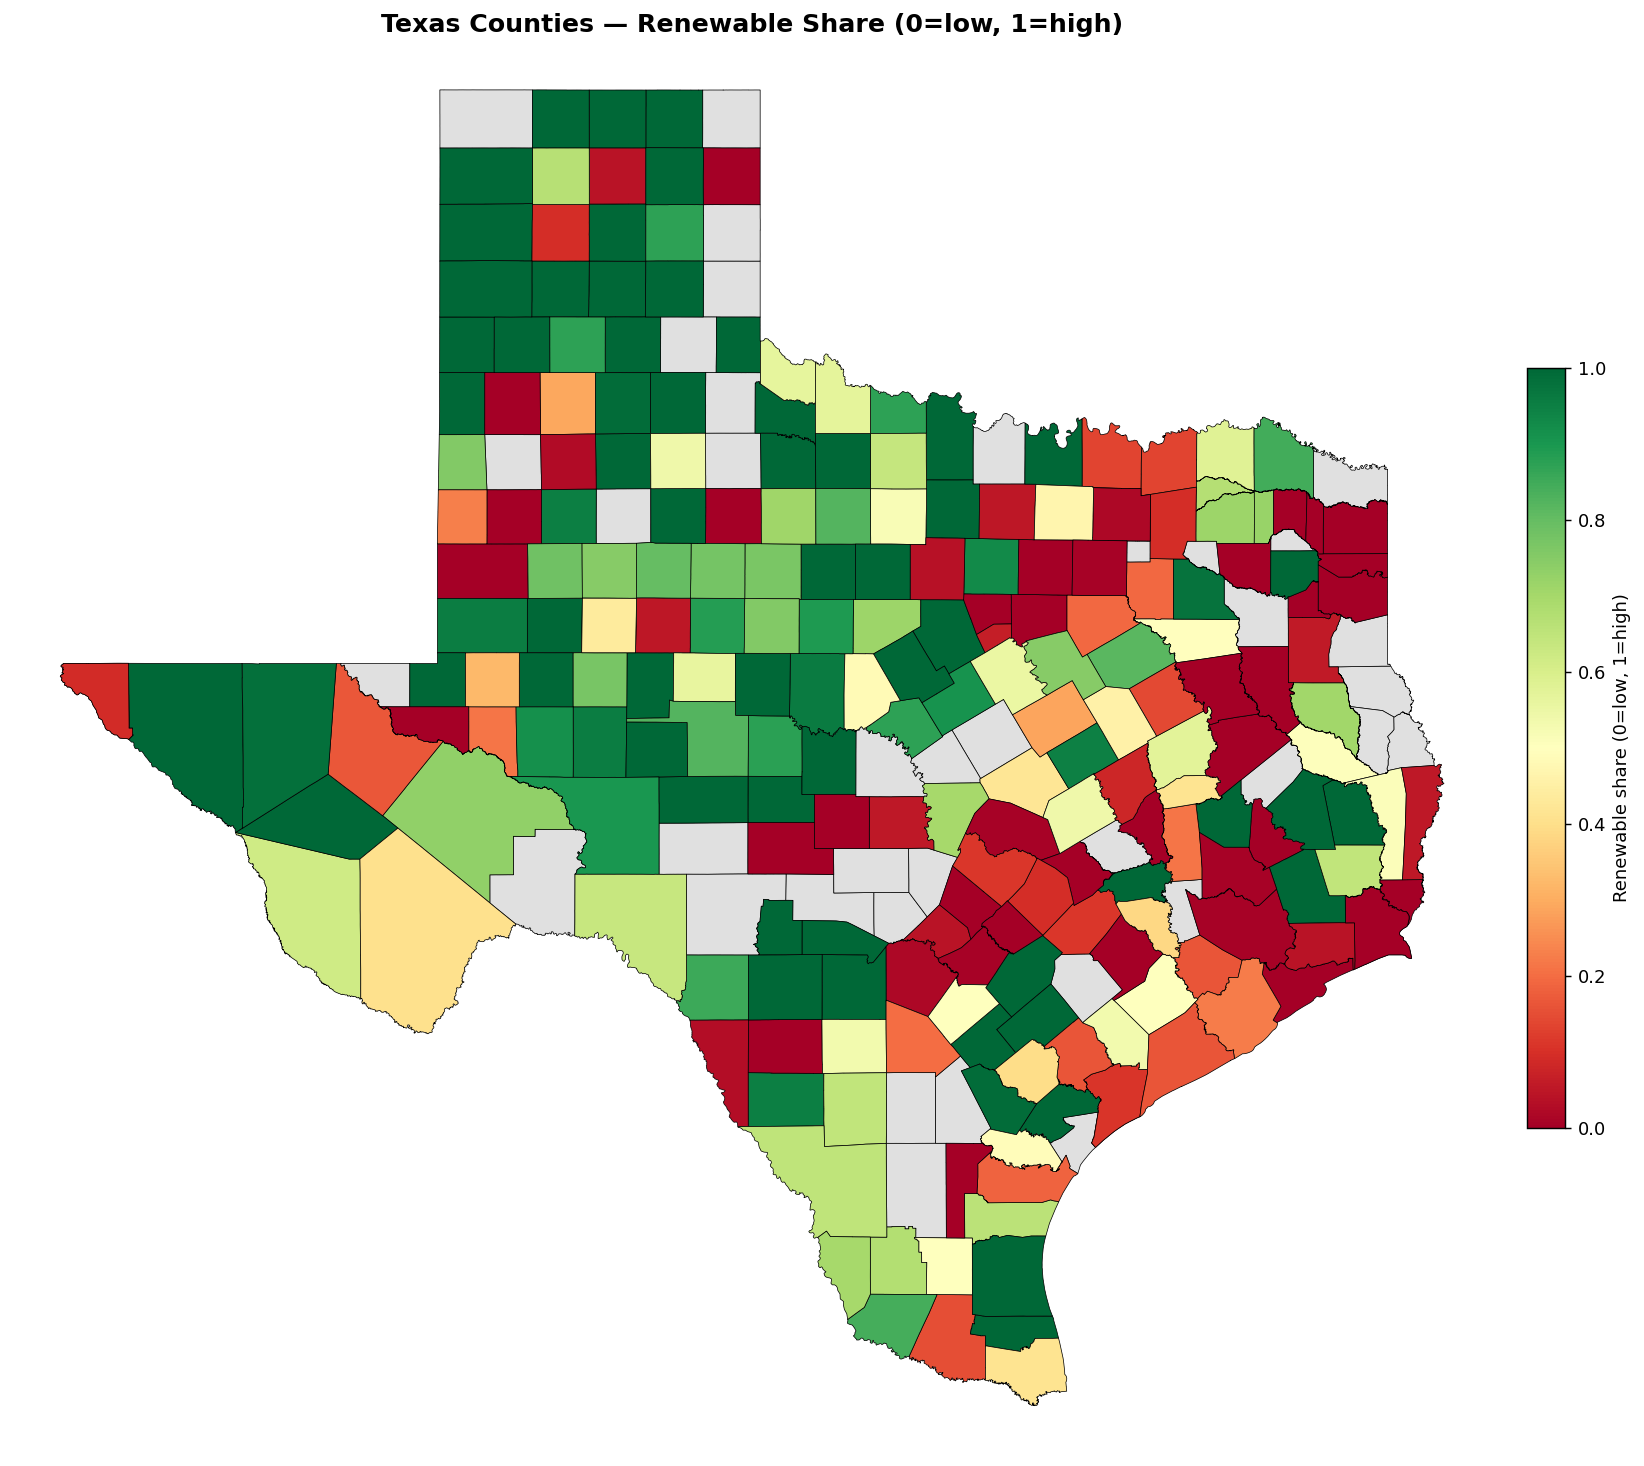

In [86]:
# Map: Texas counties by renewable share only (no bubbles) — same color scale as above
fig_renew_only, ax_ro = plt.subplots(figsize=(14, 12), dpi=130)
ax_ro.set_title("Texas Counties — Renewable Share (0=low, 1=high)", fontsize=14, fontweight="bold")
xmin, ymin, xmax, ymax = merged_3857.total_bounds
buffer = 50000
ax_ro.set_xlim(xmin - buffer, xmax + buffer)
ax_ro.set_ylim(ymin - buffer, ymax + buffer)
ax_ro.set_aspect("equal")
has_data = merged_3857["renewable_share"] >= 0
merged_3857[~has_data].plot(ax=ax_ro, color="#e0e0e0", edgecolor="black", linewidth=0.4)
merged_3857[has_data].plot(
    ax=ax_ro, column="renewable_share", cmap="RdYlGn", vmin=0, vmax=1,
    edgecolor="black", linewidth=0.4, legend=True,
    legend_kwds={"label": "Renewable share (0=low, 1=high)", "shrink": 0.5, "pad": 0.02}
)
ax_ro.set_axis_off()
plt.tight_layout()
plt.show()

## Data Centre Map

- **County fill:** Grey = no data centre. Colored = Total MW ÷ renewable share (0 = red when no renewable, green = higher ratio).
- **Bubbles:** Data centre locations, size = Total MW.

In [87]:
# --- Data Centre Map: % of data-centre MW covered by renewables ---
# Load data centres (Texas only)
dc = pd.read_excel(BASE / "data_centres_doe_texas_cleaned.xlsx", sheet_name="Data_Centres")
dc = dc[dc["Name"].astype(str).str.contains(", TX", na=False)].copy()
dc["Total MW"] = pd.to_numeric(dc["Total MW"], errors="coerce").fillna(0)
dc["county_key"] = (
    dc["Name"]
    .str.replace(r"\s*(County|Parish),\s*TX$", "", case=False, regex=True)
    .str.strip()
    .str.title()
)

# Aggregate data-centre MW by county
dc_by_county = (
    dc.groupby("county_key")["Total MW"]
    .sum()
    .reset_index()
    .rename(columns={"Total MW": "dc_total_mw"})
)

# Join with renewable MW by county (from power plants aggregation)
# by_county has: county_key, total_mw (all plants), renewable_mw, renewable_share
cov = dc_by_county.merge(
    by_county[["county_key", "renewable_mw"]],
    on="county_key",
    how="left",
)
cov["renewable_mw"] = cov["renewable_mw"].fillna(0)

# Coverage = renewable_mw / dc_total_mw (clipped 0–1). 0 when no renewables or no DC.
cov["coverage"] = 0.0
mask = cov["dc_total_mw"] > 0
cov.loc[mask, "coverage"] = (
    cov.loc[mask, "renewable_mw"] / cov.loc[mask, "dc_total_mw"]
).clip(0, 1)

# Attach to county geometries
merged_dc = merged.merge(cov[["county_key", "dc_total_mw", "coverage"]], on="county_key", how="left")
merged_dc["has_dc"] = merged_dc["dc_total_mw"].notna() & (merged_dc["dc_total_mw"] > 0)
merged_dc["coverage"] = merged_dc["coverage"].fillna(0)

# Data centre points for bubbles
dc_geom = parse_centroid(dc["Centroid"])
gdf_dc = gpd.GeoDataFrame(dc, geometry=dc_geom, crs="EPSG:4326").dropna(subset=["geometry"])

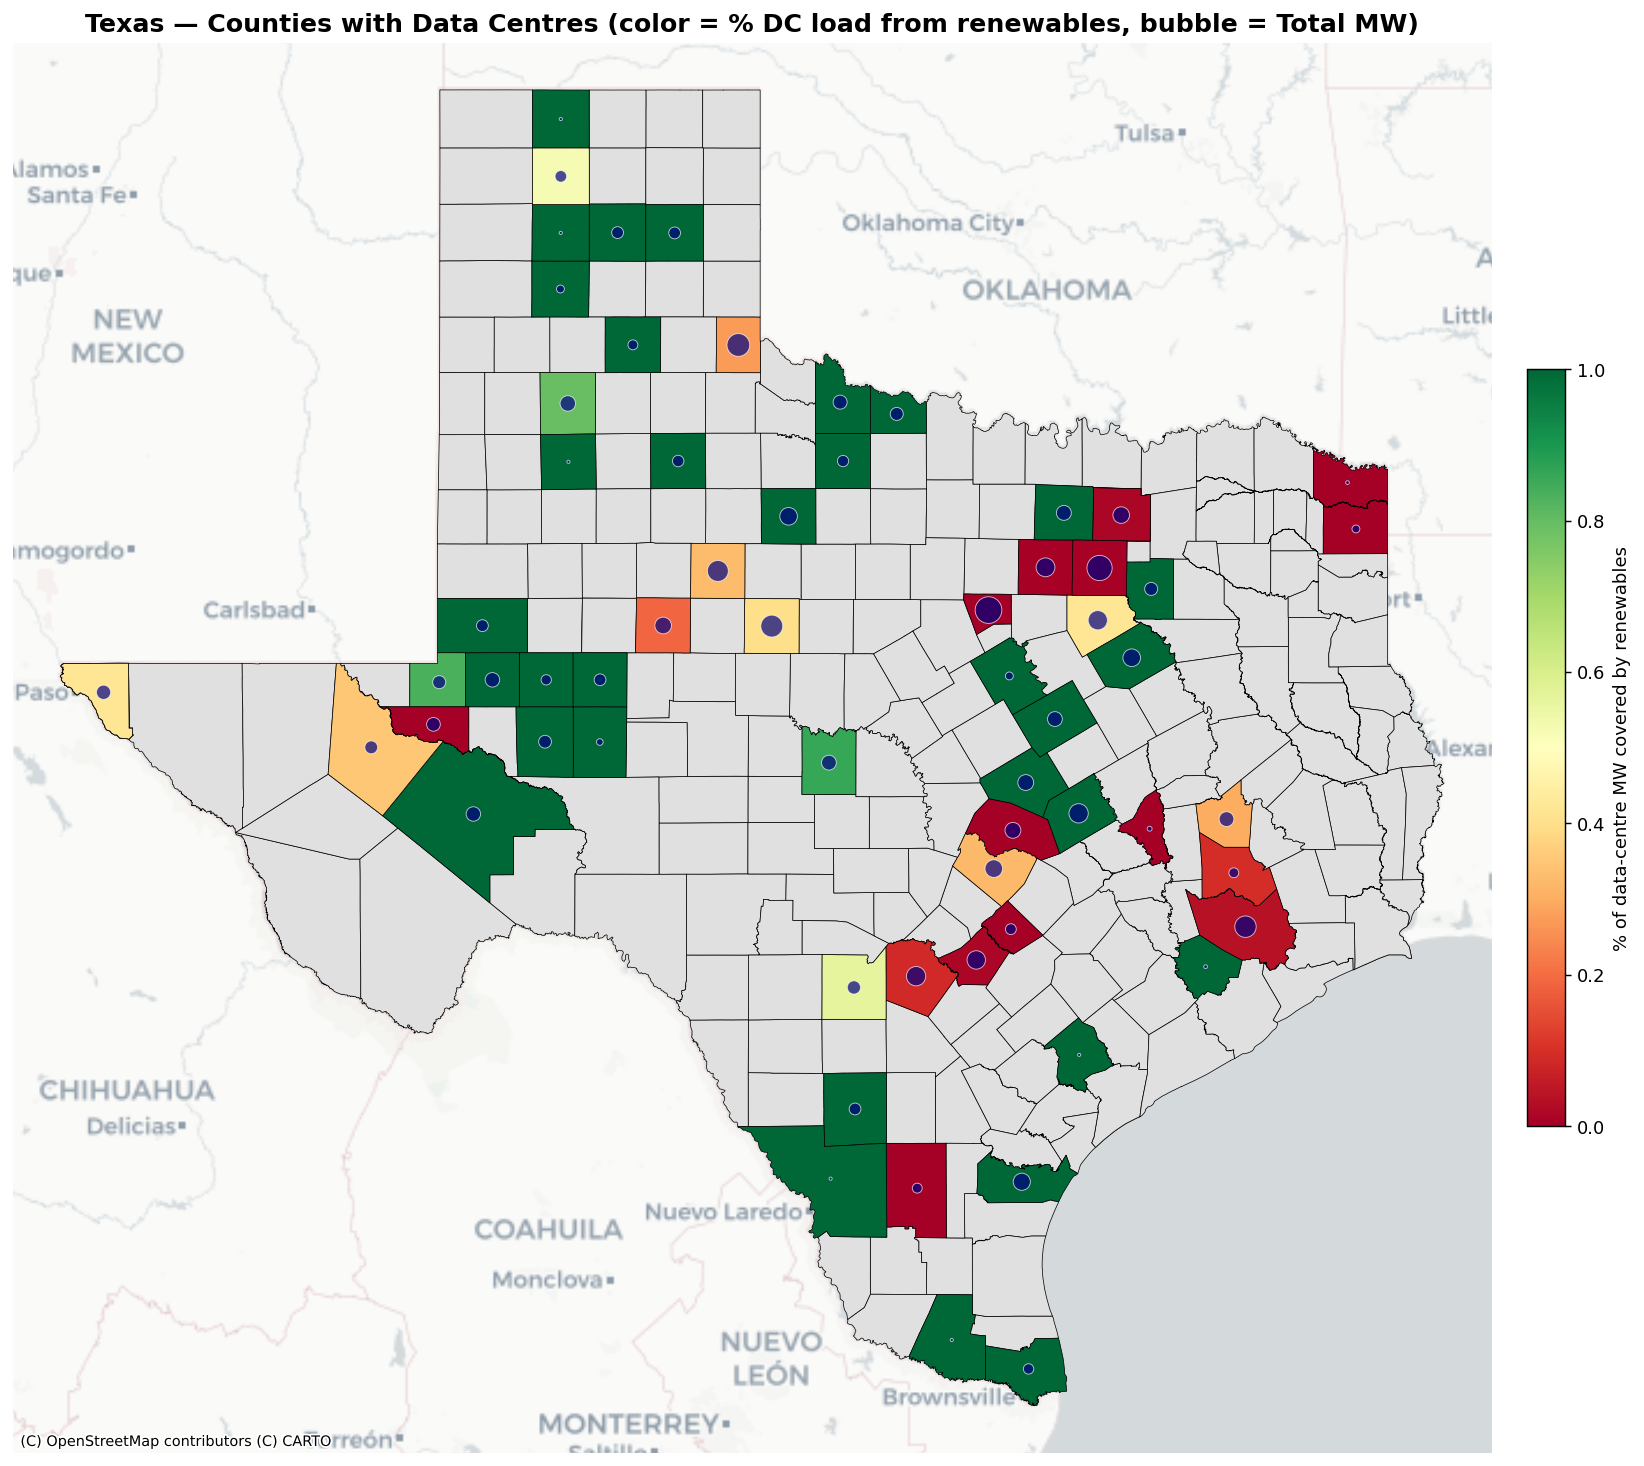

In [88]:
# Map: Only counties with a data centre — color = % of DC load from renewables, bubble size = Total MW
merged_dc_3857 = merged_dc.to_crs(epsg=3857)
gdf_dc_3857 = gdf_dc.to_crs(epsg=3857)

fig_dc_only, ax_dc = plt.subplots(figsize=(14, 12), dpi=130)
ax_dc.set_title("Texas — Counties with Data Centres (color = % DC load from renewables, bubble = Total MW)", fontsize=14, fontweight="bold")
xmin, ymin, xmax, ymax = merged_dc_3857.total_bounds
buffer = 50000
ax_dc.set_xlim(xmin - buffer, xmax + buffer)
ax_dc.set_ylim(ymin - buffer, ymax + buffer)
ax_dc.set_aspect("equal")
no_dc = ~merged_dc_3857["has_dc"]
merged_dc_3857[no_dc].plot(ax=ax_dc, color="#e0e0e0", edgecolor="black", linewidth=0.4)
has_dc = merged_dc_3857["has_dc"]
merged_dc_3857[has_dc].plot(ax=ax_dc, column="coverage", cmap="RdYlGn", vmin=0, vmax=1, edgecolor="black", linewidth=0.4, legend=True, legend_kwds={"label": "% of data-centre MW covered by renewables", "shrink": 0.5, "pad": 0.02})
mw_dc = gdf_dc_3857["Total MW"].fillna(0).clip(lower=1)
sizes_dc = (mw_dc ** 0.5) * 3
gdf_dc_3857.plot(ax=ax_dc, markersize=sizes_dc, color="navy", alpha=0.7, edgecolor="white", linewidth=0.5)
ctx.add_basemap(ax_dc, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)
ax_dc.axis("off")
plt.tight_layout()
plt.show()

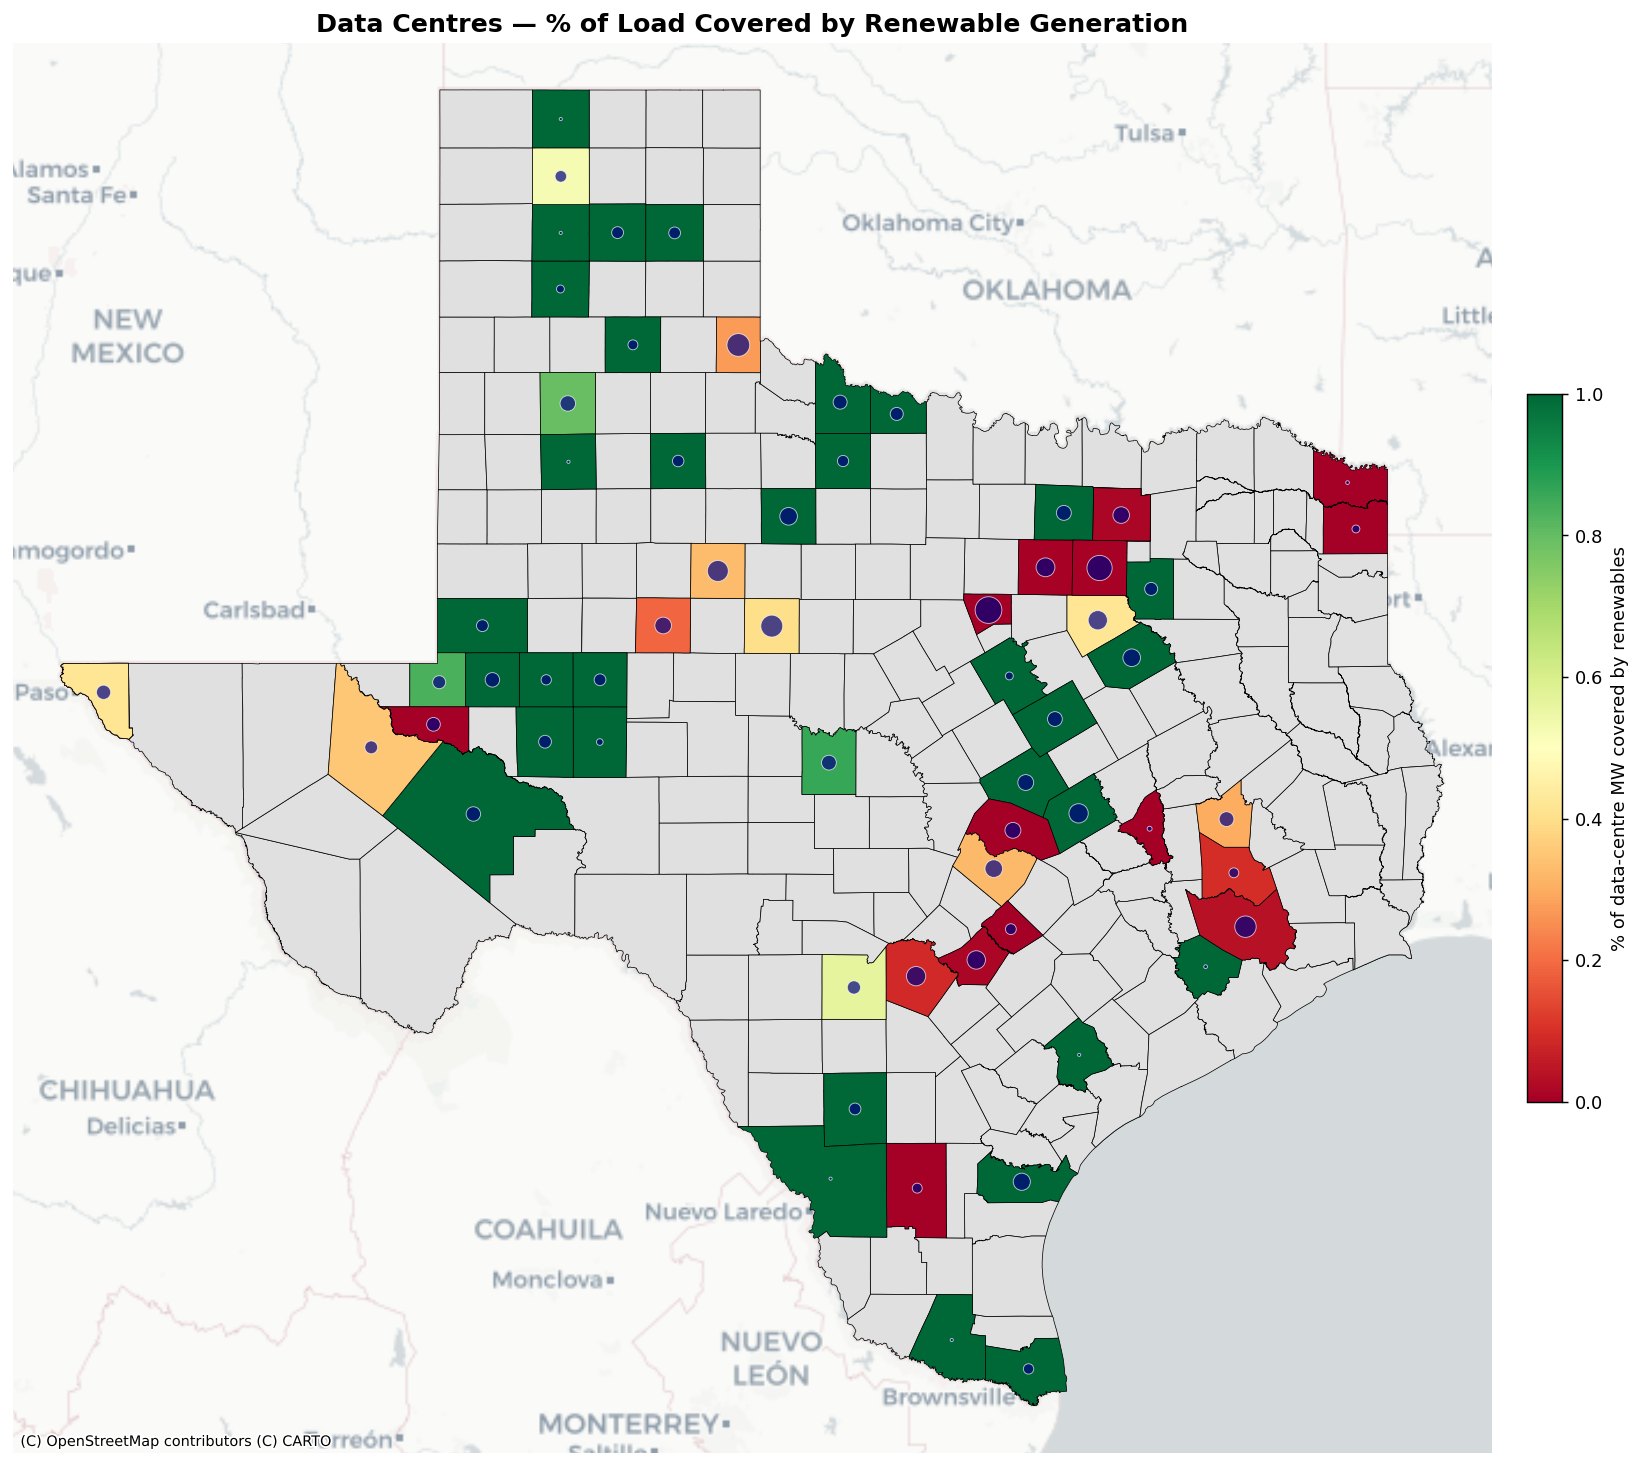

In [89]:
# Map: Data centres — county color = % of load covered by renewables, bubbles = Total MW
merged_dc_3857 = merged_dc.to_crs(epsg=3857)
gdf_dc_3857 = gdf_dc.to_crs(epsg=3857)

fig2, ax2 = plt.subplots(figsize=(14, 12), dpi=130)
ax2.set_title("Data Centres — % of Load Covered by Renewable Generation", fontsize=14, fontweight="bold")

xmin, ymin, xmax, ymax = merged_dc_3857.total_bounds
buffer = 50000
ax2.set_xlim(xmin - buffer, xmax + buffer)
ax2.set_ylim(ymin - buffer, ymax + buffer)
ax2.set_aspect("equal")

# 1. Counties: grey = no data centre; else color by coverage (0=red, 1=green)
no_dc = ~merged_dc_3857["has_dc"]
merged_dc_3857[no_dc].plot(ax=ax2, color="#e0e0e0", edgecolor="black", linewidth=0.4)

has_dc = merged_dc_3857["has_dc"]
merged_dc_3857[has_dc].plot(
    ax=ax2, column="coverage", cmap="RdYlGn", vmin=0, vmax=1,
    edgecolor="black", linewidth=0.4, legend=True,
    legend_kwds={"label": "% of data-centre MW covered by renewables", "shrink": 0.5, "pad": 0.02}
)

# 2. Data centre bubbles: size = Total MW
mw_dc = gdf_dc_3857["Total MW"].fillna(0).clip(lower=1)
sizes_dc = (mw_dc ** 0.5) * 3
gdf_dc_3857.plot(ax=ax2, markersize=sizes_dc, color="navy", alpha=0.7,
                 edgecolor="white", linewidth=0.5)

ctx.add_basemap(ax2, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)
ax2.axis("off")
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

Coverage: % of load covered by renewables. Difference = (incl. population) − (DC only) in percentage points.


,County,Coverage (DC only),Coverage (incl. population),Difference (pp),DC total MW,Population
35,Lubbock,100.0,7.2,-92.8,0.700,310633
16,Denton,100.0,31.0,-69.0,518.232,906419
39,Midland,100.0,40.1,-59.9,116.000,169986
31,Hidalgo,100.0,47.1,-52.9,0.400,870787
21,El Paso,42.1,11.2,-31.0,427.300,865661
...,...,...,...,...,...,...
56,Victoria,100.0,100.0,0.0,0.300,91322
59,Webb,100.0,100.0,0.0,0.650,267113
58,Ward,0.0,0.0,0.0,370.000,11640
61,Wilbarger,100.0,100.0,0.0,400.000,12888


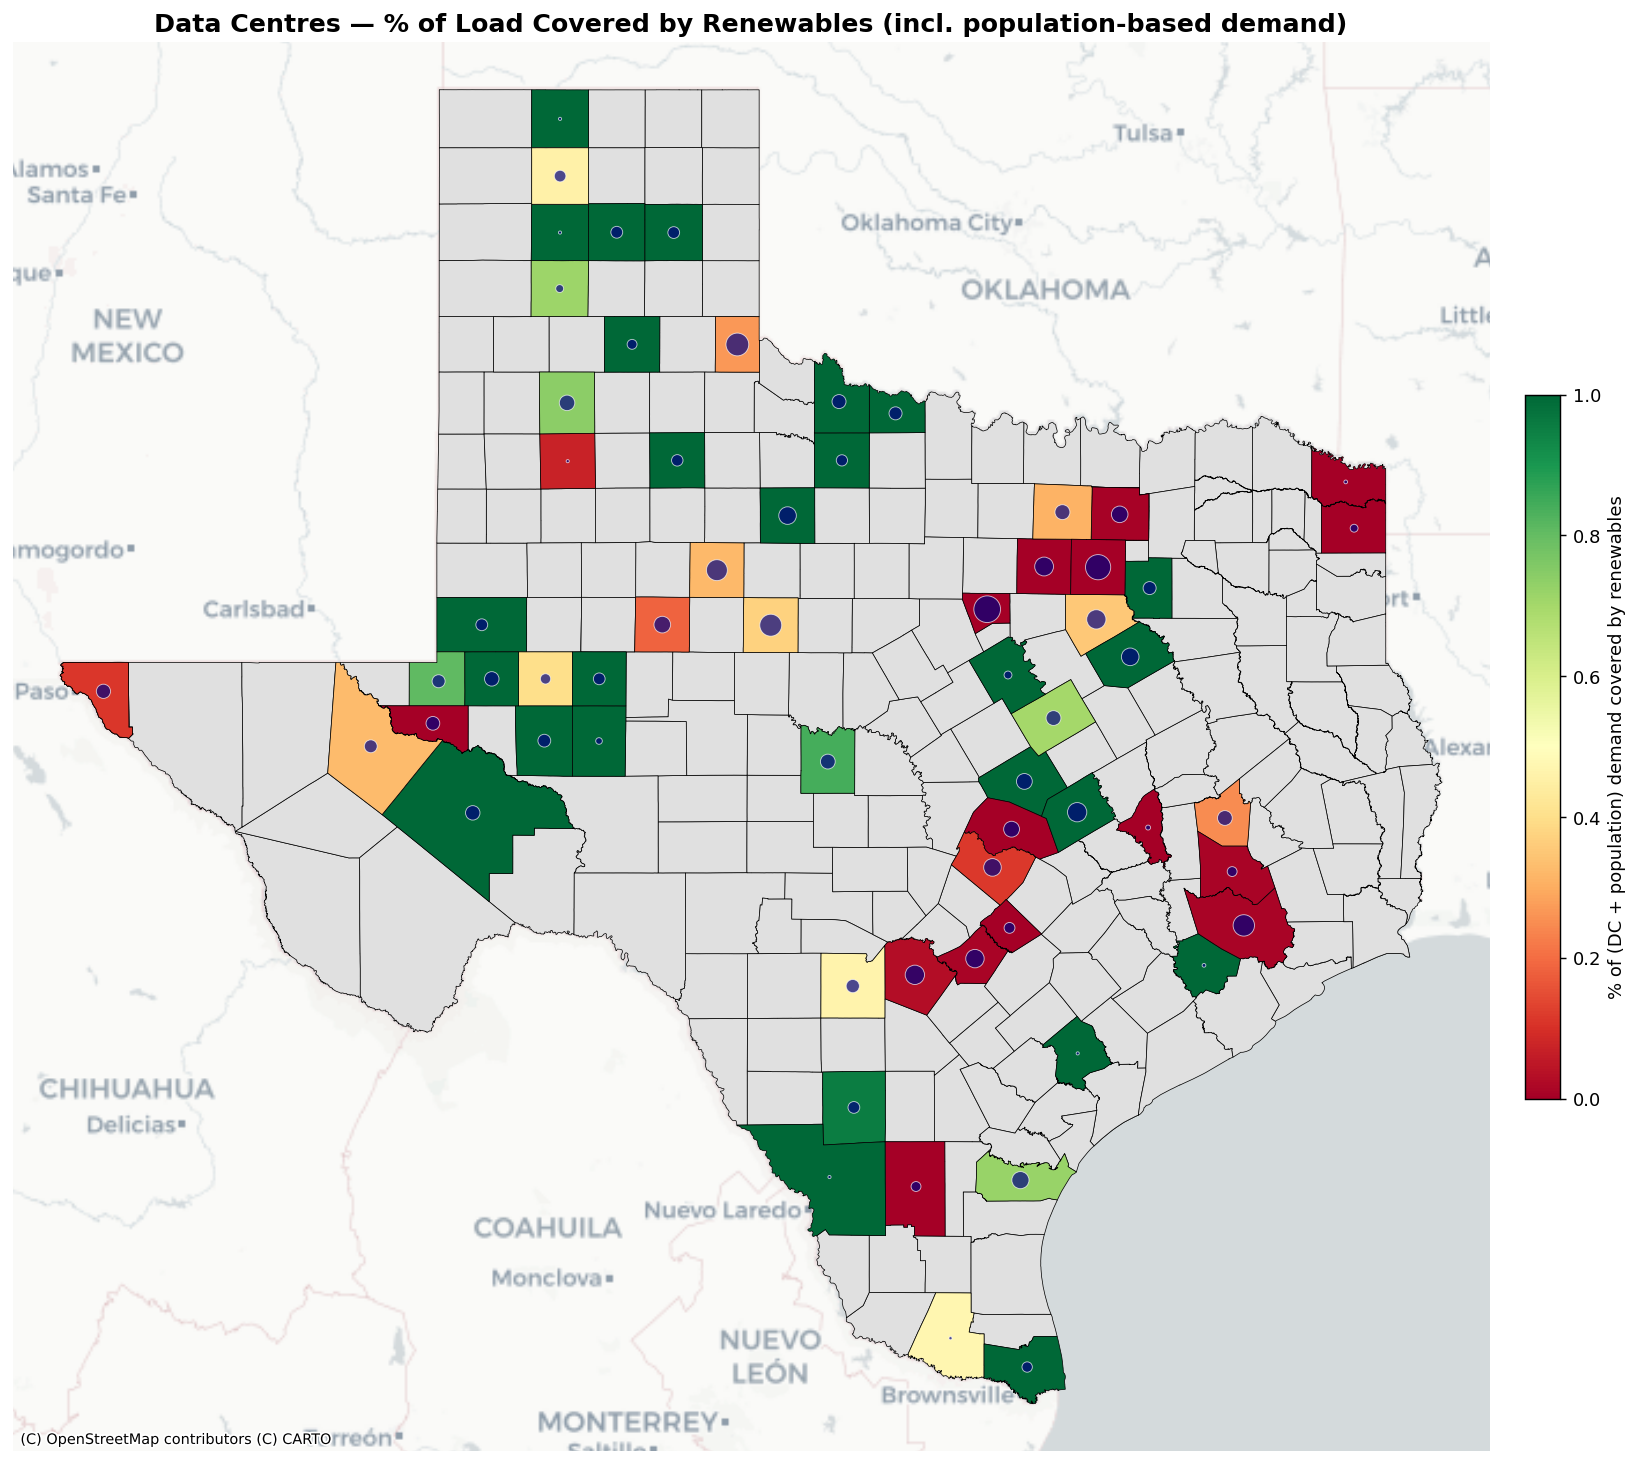

In [91]:
# Map: Same as above but coverage accounts for general energy consumption (using population)
# Load population by county from Population data sheet, Pop. 2023 = column H
pop_path = Path(r"C:\Users\pmeijer\OneDrive - Oxford Economics\Data_Centre_Sub\PopulationReport.xlsx")
pop_df = pd.read_excel(pop_path, sheet_name="Population", header=1, usecols="C,H")
pop_df = pop_df.rename(columns={pop_df.columns[0]: "county_key", pop_df.columns[1]: "population"})
pop_df["county_key"] = pop_df["county_key"].astype(str).str.strip().str.title().str.replace(" County", "").str.strip()
pop_df["population"] = pd.to_numeric(pop_df["population"], errors="coerce").fillna(0)
pop_df = pop_df[pop_df["county_key"].str.lower() != "texas"]  # drop state total row
pop_df = pop_df[["county_key", "population"]].drop_duplicates("county_key")

# Rough estimate: general electricity ~12 MWh/year per capita => ~0.00137 MW per capita (average)
MW_PER_CAPITA = 12 / 8760
cov_pop = cov.merge(pop_df, on="county_key", how="left")
cov_pop["population"] = cov_pop["population"].fillna(0)
cov_pop["general_mw"] = cov_pop["population"] * MW_PER_CAPITA
cov_pop["total_demand_mw"] = cov_pop["dc_total_mw"].fillna(0) + cov_pop["general_mw"]
cov_pop["coverage_incl_pop"] = 0.0
mask = cov_pop["total_demand_mw"] > 0
cov_pop.loc[mask, "coverage_incl_pop"] = (cov_pop.loc[mask, "renewable_mw"] / cov_pop.loc[mask, "total_demand_mw"]).clip(0, 1)
merged_dc_pop = merged.merge(cov_pop[["county_key", "dc_total_mw", "coverage_incl_pop", "population"]], on="county_key", how="left")
merged_dc_pop["has_dc"] = merged_dc_pop["dc_total_mw"].notna() & (merged_dc_pop["dc_total_mw"] > 0)
merged_dc_pop["coverage_incl_pop"] = merged_dc_pop["coverage_incl_pop"].fillna(0)
merged_dc_pop_3857 = merged_dc_pop.to_crs(epsg=3857)

# Table: difference between coverage (DC only) vs coverage (incl. population)
# cov_pop already has "coverage" (from cov) and "coverage_incl_pop"
table_compare = cov_pop[cov_pop["dc_total_mw"].fillna(0) > 0].copy()
table_compare["difference"] = table_compare["coverage_incl_pop"] - table_compare["coverage"]
table_compare = table_compare.rename(columns={"county_key": "County", "coverage": "Coverage (DC only)", "coverage_incl_pop": "Coverage (incl. population)", "difference": "Difference (pp)", "dc_total_mw": "DC total MW", "population": "Population"})
table_compare["Coverage (DC only)"] = (table_compare["Coverage (DC only)"] * 100).round(1)
table_compare["Coverage (incl. population)"] = (table_compare["Coverage (incl. population)"] * 100).round(1)
table_compare["Difference (pp)"] = (table_compare["Difference (pp)"] * 100).round(1)
table_display = table_compare[["County", "Coverage (DC only)", "Coverage (incl. population)", "Difference (pp)", "DC total MW", "Population"]].sort_values("Difference (pp)")
print("Coverage: % of load covered by renewables. Difference = (incl. population) − (DC only) in percentage points.")
display(table_display)

fig3, ax3 = plt.subplots(figsize=(14, 12), dpi=130)
ax3.set_title("Data Centres — % of Load Covered by Renewables (incl. population-based demand)", fontsize=14, fontweight="bold")
xmin, ymin, xmax, ymax = merged_dc_pop_3857.total_bounds
buffer = 50000
ax3.set_xlim(xmin - buffer, xmax + buffer)
ax3.set_ylim(ymin - buffer, ymax + buffer)
ax3.set_aspect("equal")
no_dc = ~merged_dc_pop_3857["has_dc"]
merged_dc_pop_3857[no_dc].plot(ax=ax3, color="#e0e0e0", edgecolor="black", linewidth=0.4)
has_dc = merged_dc_pop_3857["has_dc"]
merged_dc_pop_3857[has_dc].plot(ax=ax3, column="coverage_incl_pop", cmap="RdYlGn", vmin=0, vmax=1, edgecolor="black", linewidth=0.4, legend=True, legend_kwds={"label": "% of (DC + population) demand covered by renewables", "shrink": 0.5, "pad": 0.02})
gdf_dc_3857.plot(ax=ax3, markersize=sizes_dc, color="navy", alpha=0.7, edgecolor="white", linewidth=0.5)
ctx.add_basemap(ax3, crs="EPSG:3857", source=ctx.providers.CartoDB.Positron)
ax3.axis("off")
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.show()

In [92]:
# Summary: what % of data-centre MW is in counties where renewables cover < 50% of DC demand?
dc_counties = cov_pop[cov_pop["dc_total_mw"].fillna(0) > 0].copy()
total_dc_mw = dc_counties["dc_total_mw"].sum()
mw_below_50 = dc_counties.loc[dc_counties["coverage"] < 0.5, "dc_total_mw"].sum()
pct_mw_below_50 = 100 * mw_below_50 / total_dc_mw if total_dc_mw else 0

summary_table = pd.DataFrame({
    "Metric": [
        "Total data-centre MW (all counties with DC)",
        "DC MW in counties with coverage < 50%",
        "% of data-centre MW with coverage < 50%",
    ],
    "Value": [
        f"{total_dc_mw:,.1f} MW",
        f"{mw_below_50:,.1f} MW",
        f"{pct_mw_below_50:.1f}%",
    ],
})
print("Share of data-centre MW where % demand covered by renewables is below 50%:")
display(summary_table)

# Optional: list counties with DC that have coverage < 0.5
below_50 = dc_counties[dc_counties["coverage"] < 0.5][["county_key", "dc_total_mw", "coverage"]].copy()
below_50["coverage"] = (below_50["coverage"] * 100).round(1).astype(str) + "%"
below_50 = below_50.rename(columns={"county_key": "County", "dc_total_mw": "DC total MW"})
below_50["DC total MW"] = below_50["DC total MW"].round(1)
print("\nCounties with data centres where coverage < 50%:")
display(below_50)

Share of data-centre MW where % demand covered by renewables is below 50%:


,Metric,Value
0,Total data-centre MW (all counties with DC),"42,653.1 MW"
1,DC MW in counties with coverage < 50%,"30,736.2 MW"
2,% of data-centre MW with coverage < 50%,72.1%



Counties with data centres where coverage < 50%:


,County,DC total MW,coverage
3,Bexar,1453.6,8.7%
5,Bowie,2.0,0.0%
6,Brazos,6.0,0.0%
8,Caldwell,144.0,0.0%
11,Cass,40.0,0.0%
12,Childress,2800.0,27.0%
13,Collin,784.4,0.0%
14,Collin,784.4,1.4%
15,Dallas,4205.8,0.5%
18,Duval,100.0,0.0%
